# **Módulo 4: Avaliação de Modelos de Regressão - Exercício Prático**
---

Neste exercício, você irá avaliar a qualidade do modelo de regressão linear criado no módulo anterior, utilizando métricas de erro, validação cruzada e análise de resíduos sobre o dataset de preços de casas (housing_tratado.csv).

1. **Execute a primeira célula** para carregar o dataset.
2. Siga as instruções ao longo do notebook — os **comentários nas células indicam exatamente o que deve ser feito**, e os locais onde você deve preencher o código estarão claramente marcados com `'aqui'`, para facilitar o processo.
3. No final, utilize os resultados obtidos para responder às perguntas no espaço indicado no material do curso.


Execute a célula abaixo para começar.

## **Carregamento e Preparação dos Dados**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/TreinamentoICCInatel/Curso_Regressao_na_Pratica/refs/heads/main/Arquivos/housing_tratado.csv"
housing = pd.read_csv(url)

# Use o comando head para verificar se o dataset foi carregado corretamente

In [ ]:
X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Modelo treinado. Pronto para avaliação.")

Modelo treinado. Pronto para avaliação.


## **Avaliando o Modelo com Métricas**

Importe, separando por vírgulas, as métricas necessárias do sklearn.metrics: `mean_absolute_error`, `mean_squared_error` e `r2_score` para que seja possível realizar o cálculo do erro absoluto médio, erro quadrático médio, raiz do erro quadrático médio e o coeficiente de determinação R².

In [ ]:
from sklearn.metrics import 'aqui'

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE:  {mae:.2f}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE:  {mse:.2f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

r2 = r2_score(y_test, y_pred)
print(f"R²:   {r2:.3f}")

#### **1. Qual alternativa representa corretamente os resultados obtidos?**

a) MAE = 0,46 MSE = 0,39 RMSE = 0,62 R² = 0,618

b) MAE = 0,44 MSE = 0,37 RMSE = 0,61 R² = 0,625

c) MAE = 0,45 MSE = 0,36 RMSE = 0,60 R² = 0,632

d) MAE = 0,43 MSE = 0,38 RMSE = 0,63 R² = 0,610

## **Validação Cruzada (Cross Validation)**

Nesta etapa, utilizaremos o método de validação cruzada em conjunto com a função cross_val_score.
Para isso, configure a estratégia de validação K-Fold com 6 divisões e defina a métrica de avaliação do `cross_val_score` como R² ('r2').

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# Definindo a estratégia de validação
kfold = KFold(n_splits='aqui', shuffle=True, random_state=42)

# Calculando o R2 médio
cv_r2_scores = cross_val_score(model, X, y, cv=kfold, scoring='aqui')

print("Resultados da Validação Cruzada (6 Folds):")
print(f"R2 em cada fold: {cv_r2_scores}")
print(f"R2 Médio:        {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std():.4f})")

Resultados da Validação Cruzada (6 Folds):
R2 em cada fold: [0.61634141 0.66376409 0.64028124 0.66798515 0.64739272 0.62075892]
R2 Médio:        0.6428 (+/- 0.0195)


#### **2. Com base na saída do bloco de código assinale a alternativa correta**

a) O valor do R² no último fold é 0,64739272 e o R² médio é 0,6402.

b) O R² observado no último fold é 0,61634141 e a média dos R² é 0,6679.

c) O valor do R² no último fold é 0,62075892 e o R² médio calculado é 0,6428.

d) O último fold apresenta R² igual a 0,66376409 e o desempenho médio é 0,6410.

## **Diagnosticando resíduos**

Nesta etapa, analisaremos os resíduos do modelo, que correspondem à diferença entre os valores reais e os valores preditos.

Para isso, complete a expressão utilizando a variável `y_test`, de modo que os resíduos sejam obtidos pela subtração entre os valores observados e as predições do modelo.

In [ ]:
import statsmodels.api as sm

# Calcular resíduos do conjunto de teste
residuals = 'aqui' - y_pred

#### **Gerando visualização**

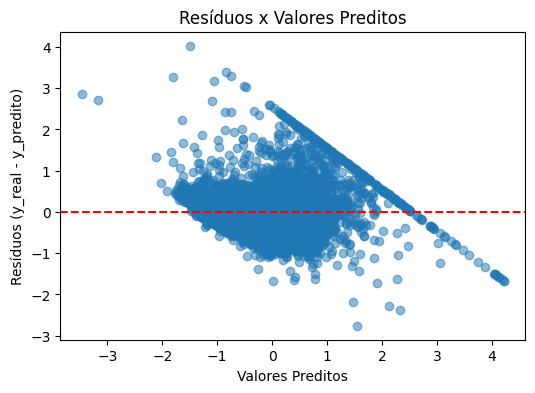

In [ ]:
# O gráfico deste bloco de código será exibido após a execução correta das etapas/instruções acima.
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos (y_real - y_predito)")
plt.title("Resíduos x Valores Preditos")
plt.show()

**3. Ao analisar o gráfico de resíduos do modelo, assinale a alternativa que apresenta a interpretação mais adequada:**

a) Os resíduos estão distribuídos aleatoriamente e com variância constante, indicando que o modelo atende plenamente às suposições de homocedasticidade e não apresenta problemas de ajuste.

b) Observa-se que os resíduos não se aproximam da linha y=0, revelando forte viés sistemático e indicando que o modelo superestima os valores em toda a faixa analisada.

c) Embora os resíduos estejam, em média, próximos de y=0, há um padrão perceptível e mudanças na amplitude da dispersão ao longo dos valores previstos, sugerindo variância não constante e possível dificuldade do modelo em representar completamente os dados.

d) A presença de alguns resíduos extremos indica apenas a existência de outliers isolados, sem impacto nas premissas do modelo ou na qualidade do ajuste global.

#### **Gerando visualização**

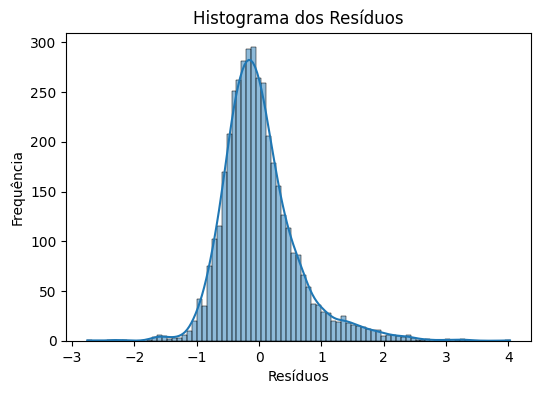

In [ ]:
# O gráfico deste bloco de código será exibido após a execução correta das etapas/instruções acima.
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Histograma dos Resíduos")
plt.show()

**4. Com base na análise do histograma dos resíduos do modelo, assinale a alternativa correta:**

a) A distribuição dos resíduos é aproximadamente uniforme, indicando que os erros se espalham de maneira homogênea e sem qualquer padrão relevante.

b) O histograma apresenta formato perfeitamente simétrico e centrado, caracterizando uma distribuição normal ideal e ausência de valores discrepantes.

c) A maior parte dos resíduos encontra-se distante de zero, evidenciando que o modelo produz erros elevados de forma sistemática.

d) Nota-se que os resíduos se acumulam próximos de zero, o que sugere predominância de erros de pequena magnitude; entretanto, há uma assimetria com alongamento à direita, indicando ocorrência de erros positivos mais extremos e possível afastamento da normalidade.

---

Com isso, concluímos nossa exploração da **avaliação de modelos de regressão**. Neste módulo, você aprendeu a utilizar métricas essenciais como MAE, MSE, RMSE e R² para quantificar o desempenho de um modelo. Além disso, aplicou a **validação cruzada (K-Fold)** para garantir a robustez das suas avaliações e a **análise de resíduos** para diagnosticar o comportamento do modelo e identificar possíveis problemas.

Estas técnicas são fundamentais para entender as forças e fraquezas de qualquer modelo de regressão, permitindo que você tome decisões informadas sobre ajustes e melhorias. Sinta-se à vontade para experimentar com diferentes configurações de validação cruzada, explorar mais a fundo os resíduos ou aplicar essas métricas a outros modelos.

 Essas habilidades são cruciais para a construção de modelos preditivos eficazes!